In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [40]:
df=pd.read_csv("future50.csv")
df
# print(df)
# df.head(50)
# df.columns

,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
0,1,Evergreens,"Seattle, Wash.",24,130.50%,26,116.70%,1150,No
1,2,Clean Juice,"Charlotte, N.C.",44,121.90%,105,94.40%,560,Yes
2,3,Slapfish,"Huntington Beach, Calif.",21,81.00%,21,90.90%,1370,Yes
3,4,Clean Eatz,"Wilmington, N.C.",25,79.70%,46,58.60%,685,Yes
4,5,Pokeworks,"Irvine, Calif.",49,77.10%,50,56.30%,1210,Yes
5,6,Playa Bowls,"Belmar, N.J.",39,62.90%,76,28.80%,580,Yes
6,7,The Simple Greek,"Blue Bell, Pa.",24,52.50%,36,33.30%,775,Yes
7,8,Melt Shop,"New York, N.Y.",20,39.60%,19,35.70%,1260,Yes
8,9,Creamistry,"Yorba Linda, Calif.",24,36.80%,60,27.70%,465,Yes
9,10,Joella's Hot Chicken,"Louisville, Ky.",29,35.50%,17,30.80%,1930,No


In [41]:
df.isnull().sum()

Rank           0
Restaurant     0
Location       0
Sales          0
YOY_Sales      0
Units          0
YOY_Units      0
Unit_Volume    0
Franchising    0
dtype: int64

In [42]:
df.duplicated(subset=['Restaurant','Location']).sum()

np.int64(0)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rank         50 non-null     int64 
 1   Restaurant   50 non-null     object
 2   Location     50 non-null     object
 3   Sales        50 non-null     int64 
 4   YOY_Sales    50 non-null     object
 5   Units        50 non-null     int64 
 6   YOY_Units    50 non-null     object
 7   Unit_Volume  50 non-null     int64 
 8   Franchising  50 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.6+ KB


In [44]:
df.describe()

,Rank,Sales,Units,Unit_Volume
count,50.00000,50.000000,50.000000,50.00000
mean,25.50000,33.780000,34.700000,1592.60000
std,14.57738,9.596534,24.527577,994.67677
min,1.00000,20.000000,7.000000,465.00000
25%,13.25000,24.250000,16.000000,867.50000
50%,25.50000,34.500000,27.000000,1260.00000
75%,37.75000,42.000000,45.500000,2020.00000
max,50.00000,49.000000,105.000000,4300.00000


Restaurant having highest sale

In [45]:
df.sort_values(by='Sales', ascending=False).head(5)

,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
4,5,Pokeworks,"Irvine, Calif.",49,77.10%,50,56.30%,1210,Yes
40,41,Blue Sushi Sake Grill,"Omaha, Neb.",49,19.50%,14,16.70%,3500,No
45,46,LA Crawfish,"McAllen, Texas",48,17.60%,25,13.60%,2050,Yes
13,14,Bluestone Lane,"New York, N.Y.",48,33.00%,48,37.10%,1175,No
41,42,The Human Bean,"Medford, Ore.",47,19.00%,97,19.80%,535,Yes


In [46]:
top4=df.sort_values(by='YOY_Sales', ascending=False).head(4)
top4

,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
2,3,Slapfish,"Huntington Beach, Calif.",21,81.00%,21,90.90%,1370,Yes
3,4,Clean Eatz,"Wilmington, N.C.",25,79.70%,46,58.60%,685,Yes
4,5,Pokeworks,"Irvine, Calif.",49,77.10%,50,56.30%,1210,Yes
5,6,Playa Bowls,"Belmar, N.J.",39,62.90%,76,28.80%,580,Yes


The data indicates that higher current sales do not necessarily result in higher YOY growth. while pokeworks and Blue sushi sake grill recorded the highest sales(49 million USD),slapfish and clean Eatz achieved stronger YOY sales growth. A likely explaination is that pokeworks and Blue sushi grill started from a larger sales base in a previous year, Whereas Slapfish and Clean Eatz experienced a faster growth from a lower base.

{'whiskers': [<matplotlib.lines.Line2D at 0x1775b7e5e50>,
 'caps': [<matplotlib.lines.Line2D at 0x1775b7e60d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1775b7e5d10>],
 'medians': [<matplotlib.lines.Line2D at 0x1775b7e6350>],
 'fliers': [<matplotlib.lines.Line2D at 0x1775b7e6490>],
 'means': []}

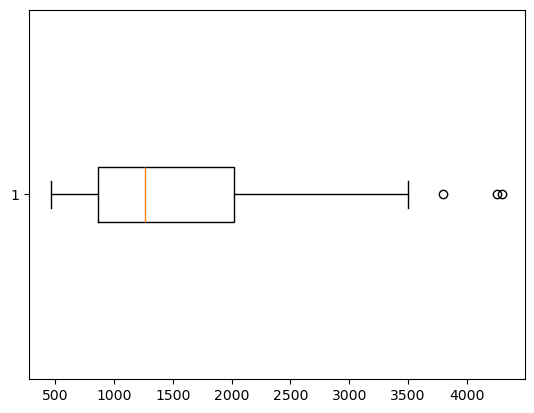

In [47]:
plt.boxplot(df['Unit_Volume'],vert=False)

In [48]:
def detect_outliers_iqr(df,Unit_Volume):
 Q1=df[Unit_Volume].quantile(0.25)
 Q3=df[Unit_Volume].quantile(0.75)
 IQR=Q3-Q1
 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR
 outliers=df[(df[Unit_Volume]<lower_bound)| (df[Unit_Volume]>upper_bound)]
 return outliers,Q1,Q3,lower_bound,upper_bound

outliers,Q1,Q3,lower_bound,upper_bound=detect_outliers_iqr(df,'Unit_Volume')

print("Q1:",Q1)
print("Q3:",Q3)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

print("Number of outliers detected:",len(outliers))
outliers

Q1: 867.5
Q3: 2020.0
lower_bound: -861.25
upper_bound: 3748.75
Number of outliers detected: 3


,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
18,19,Hawkers Asian Street Fare,"Orlando, Fla.",22,30.00%,7,40.00%,3800,No
20,21,Bulla Gastrobar,"Doral, Fla.",32,28.20%,8,14.30%,4300,No
33,34,Boqueria,"New York, N.Y.",27,22.00%,7,16.70%,4260,No


Three restaurants were identified as outliers in the unit_volume variable using the IQR method.since these value likely represent restaurants with exceptionally high sales per outlets rather than data errors, they were retained for the data analysis.

In [49]:
df['Franchising'].value_counts()
# print(df.columns)

Franchising
Yes    29
No     21
Name: count, dtype: int64

In [50]:
df[df['Franchising']=='Yes'].sort_values(by='Sales',ascending=False,).reset_index().head(50)

,index,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
0,4,5,Pokeworks,"Irvine, Calif.",49,77.10%,50,56.30%,1210,Yes
1,45,46,LA Crawfish,"McAllen, Texas",48,17.60%,25,13.60%,2050,Yes
2,41,42,The Human Bean,"Medford, Ore.",47,19.00%,97,19.80%,535,Yes
3,23,24,Joe & The Juice,"New York, N.Y.",47,25.90%,69,25.50%,760,Yes
4,1,2,Clean Juice,"Charlotte, N.C.",44,121.90%,105,94.40%,560,Yes
5,16,17,Ike's Love & Sandwiches,"San Francisco, Calif.",44,30.80%,71,29.10%,700,Yes
6,21,22,Duck Donuts,"Mechanicsburg, Pa.",44,28.00%,90,16.90%,530,Yes
7,49,50,Gus's World Famous Fried Chicken,"Memphis, Tenn.",44,14.40%,28,7.70%,1600,Yes
8,12,13,Teriyaki Madness,"Denver, Colo.",41,34.10%,63,65.80%,890,Yes
9,36,37,Famous Toastery,"Charlotte, N.C.",40,21.20%,27,8.00%,1540,Yes


In [51]:
df[df['Franchising']=='No'].sort_values(by='Sales',ascending=False).head(50).reset_index()

,index,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
0,40,41,Blue Sushi Sake Grill,"Omaha, Neb.",49,19.50%,14,16.70%,3500,No
1,13,14,Bluestone Lane,"New York, N.Y.",48,33.00%,48,37.10%,1175,No
2,46,47,&pizza,"Washington, D.C.",45,17.10%,35,9.40%,1350,No
3,26,27,Bibibop Asian Grill,"Columbus, Ohio",44,24.60%,37,23.30%,1330,No
4,31,32,Just Salad,"New York, N.Y.",42,22.70%,38,26.70%,1240,No
5,32,33,Jeni's Splendid Ice Creams,"Columbus, Ohio",42,22.40%,44,22.20%,1050,No
6,47,48,Super Duper Burgers,"San Francisco, Calif.",39,16.90%,16,14.30%,2630,No
7,25,26,Sugarfire Smokehouse,"Olivette, Mo.",39,25.40%,15,15.40%,2820,No
8,38,39,Condado Tacos,"Columbus, Ohio",38,19.90%,15,15.40%,2755,No
9,24,25,By Chloe,"New York, N.Y.",37,25.60%,14,7.70%,2800,No


Based on the top selling restaurants, both franchised and non franchhised restaurant chains achieve similar sales. Therefore, franchising alone does not appear to determine higher sales.suggesting that other factore such as brand reputaion, menu, operational efficiency, customer expectations,etc may also influence sales.

In [15]:
df.dtypes

Rank            int64
Restaurant     object
Location       object
Sales           int64
YOY_Sales      object
Units           int64
YOY_Units      object
Unit_Volume     int64
Franchising    object
dtype: object

In [ ]:
# df['YOY_Sales']=df['YOY_Sales'].str.rstrip('%').astype(float)
# df['YOY_Units']=df['YOY_Units'].str.rstrip('%').astype(float)
df.dtypes


Rank             int64
Restaurant      object
Location        object
Sales            int64
YOY_Sales      float64
Units            int64
YOY_Units      float64
Unit_Volume      int64
Franchising     object
dtype: object

In [55]:
df.groupby('Franchising')[['Sales','YOY_Units','YOY_Sales','Unit_Volume','Units']].mean()

,Sales,YOY_Units,YOY_Sales,Unit_Volume,Units
Franchising,,,,,
No,33.714286,24.047619,29.138095,2380.714286,19.904762
Yes,33.827586,29.906897,37.000000,1021.896552,45.413793


According to the generated ouput, Franchised restaurant  have comparatively higher Average sales,YOY_Sales,YOY_Units than non franchised restaurants.However,they have a lower average Unit_Volume than non franchised restaurant.

In [56]:
df[['Sales','Unit_Volume','Units']].corr()

,Sales,Unit_Volume,Units
Sales,1.000000,-0.117048,0.504153
Unit_Volume,-0.117048,1.000000,-0.712994
Units,0.504153,-0.712994,1.000000


There was moderate positive relationship between sales and units as more number of units are generating high overall sales.However there was very weak negative relationship between sales vs unit_volume and strong negative relationship between units vs unit_volume.


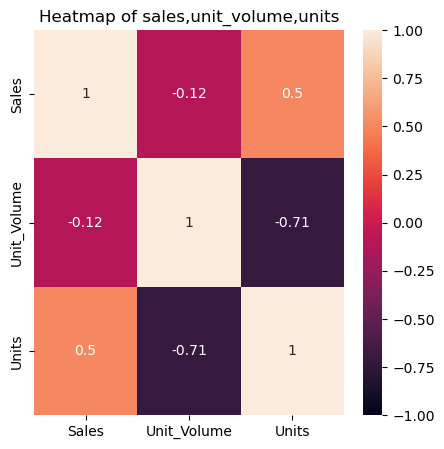

In [57]:
corr=df[['Sales','Unit_Volume','Units']].corr()
plt.figure(figsize=(5,5))
sns.heatmap(corr,color='blue',annot=True,vmin=-1,vmax=1)
plt.title('Heatmap of sales,unit_volume,units')
plt.show()


In [59]:
df.to_csv("cleaned_restaurantsales.csv",index=False)

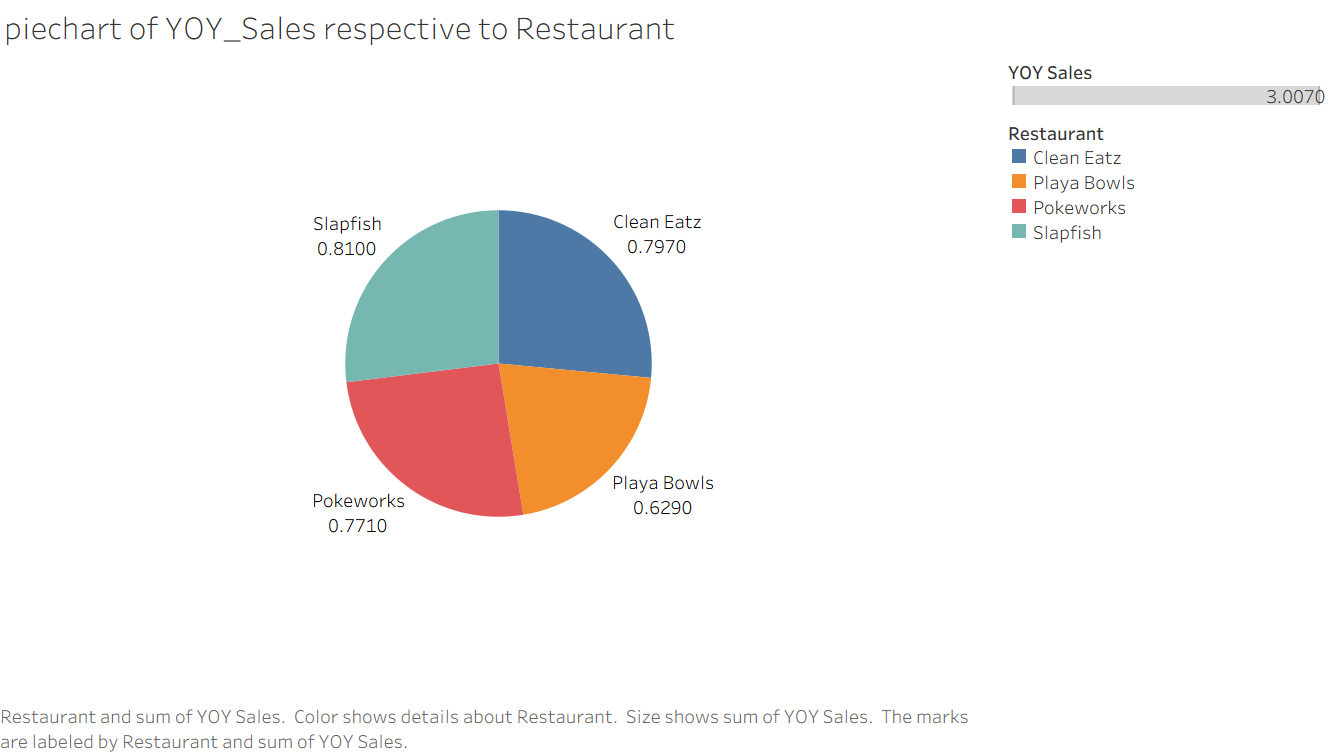

In [58]:
from IPython.display import Image

Image(filename='Piechart_sales.png')

In [60]:
type(df)

pandas.core.frame.DataFrame